In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

riders   = pd.read_csv('../data/processed/riders_cleaned.csv', parse_dates=['signup_date'])
sessions = pd.read_csv('../data/processed/sessions_cleaned.csv', parse_dates=['session_time'])
trips    = pd.read_csv('../data/processed/trips_cleaned.csv', parse_dates=['pickup_time', 'dropoff_time'])


In [2]:
# Target variable

riders['churn'] = (riders['churn_prob'] >= 0.5).astype(int)
print(f"Churn rate: {riders['churn'].mean():.2%}")
print(riders['churn'].value_counts())


Churn rate: 10.63%
churn
0    8937
1    1063
Name: count, dtype: int64


In [8]:
# Riders features

ref_date = pd.Timestamp.today()
riders['tenure_days'] = (ref_date - riders['signup_date']).dt.days

loyalty_order = {'Bronze': 1, 'Silver': 2, 'Gold': 3, 'Platinum': 4}
riders['loyalty_encoded'] = riders['loyalty_status'].map(loyalty_order)

city_dummies = pd.get_dummies(riders['city'], prefix='city', drop_first=True)

# NEW: how many riders each user referred
referral_counts = riders.groupby('referred_by')['user_id'].count()\
                        .reset_index()\
                        .rename(columns={'referred_by': 'user_id', 'user_id': 'riders_referred'})

riders = riders.merge(referral_counts, on='user_id', how='left')
riders['riders_referred'] = riders['riders_referred'].fillna(0)

rider_features = pd.concat([
    riders[['user_id', 'age', 'avg_rating_given', 'loyalty_encoded',
            'tenure_days', 'riders_referred', 'churn']],
    city_dummies
], axis=1)

rider_features.head()



,user_id,age,avg_rating_given,loyalty_encoded,tenure_days,riders_referred,churn,city_Lagos,city_Nairobi
0,R00000,34.729629,5.0,1,518,6.0,0,False,True
1,R00001,34.571020,4.7,1,655,33.0,1,False,True
2,R00002,47.133960,4.2,1,657,46.0,1,True,False
3,R00003,41.658628,4.9,1,466,3.0,0,False,True
4,R00004,40.681709,3.9,2,675,20.0,0,True,False


In [4]:
# Sessions features
session_agg = sessions.groupby('rider_id').agg(
    total_sessions  = ('session_id',  'count'),
    conversion_rate = ('converted',   'mean'),
    avg_time_on_app = ('time_on_app', 'mean'),
).reset_index().rename(columns={'rider_id': 'user_id'})

rider_features = rider_features.merge(session_agg, on='user_id', how='left')

# Fill NaN for 71 riders with no sessions
rider_features[['total_sessions', 'conversion_rate', 'avg_time_on_app']] = \
    rider_features[['total_sessions', 'conversion_rate', 'avg_time_on_app']].fillna(0)


In [9]:
# Trips features

# Trip duration
trips['trip_duration_mins'] = (
    trips['dropoff_time'] - trips['pickup_time']
).dt.total_seconds() / 60

# NEW: Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

trips['trip_distance_km'] = haversine(
    trips['pickup_lat'], trips['pickup_lng'],
    trips['dropoff_lat'], trips['dropoff_lng']
)

# NEW: Peak hour flag (7-9am, 5-7pm)
trips['hour'] = trips['pickup_time'].dt.hour
trips['is_peak'] = (
    trips['hour'].between(7, 9) | trips['hour'].between(17, 19)
).astype(int)

ref_trip_date = trips['pickup_time'].max()

trip_agg = trips.groupby('user_id').agg(
    total_trips          = ('trip_id',            'count'),
    avg_fare             = ('fare',               'mean'),
    avg_tip              = ('tip',                'mean'),
    tip_rate             = ('tip',                lambda x: (x > 0).mean()),
    avg_trip_duration    = ('trip_duration_mins', 'mean'),
    days_since_last_trip = ('pickup_time',        lambda x: (ref_trip_date - x.max()).days),
    days_active          = ('pickup_time',        lambda x: (x.max() - x.min()).days),
    avg_trip_distance    = ('trip_distance_km',   'mean'),
    peak_hour_ratio      = ('is_peak',            'mean'),
).reset_index()

# NEW: trip rate (frequency normalized by active period)
trip_agg['trip_rate'] = trip_agg['total_trips'] / (trip_agg['days_active'] + 1)

# NEW: activity decline (recent 60 days vs historical)
ref_trip_date = trips['pickup_time'].max()
recent   = trips[trips['pickup_time'] >= ref_trip_date - pd.Timedelta(days=60)]
historic = trips[trips['pickup_time'] <  ref_trip_date - pd.Timedelta(days=60)]

recent_agg = recent.groupby('user_id').agg(
    recent_trips = ('trip_id', 'count'),
    recent_spend = ('fare',    'sum')
).reset_index()

historic_agg = historic.groupby('user_id').agg(
    historic_trips = ('trip_id', 'count'),
).reset_index()

activity = recent_agg.merge(historic_agg, on='user_id', how='outer').fillna(0)
activity['activity_decline'] = activity['recent_trips'] / (activity['historic_trips'] + 1)

trip_agg = trip_agg.merge(activity[['user_id', 'activity_decline']], on='user_id', how='left')

rider_features = rider_features.merge(trip_agg, on='user_id', how='left')
print(rider_features.shape)
rider_features.head()



(10000, 20)


,user_id,age,avg_rating_given,loyalty_encoded,tenure_days,riders_referred,churn,city_Lagos,city_Nairobi,total_trips,avg_fare,avg_tip,tip_rate,avg_trip_duration,days_since_last_trip,days_active,avg_trip_distance,peak_hour_ratio,trip_rate,activity_decline
0,R00000,34.729629,5.0,1,518,6.0,0,False,True,25,14.642000,0.161200,0.400000,30.320000,25,336,3.945567,0.200000,0.074184,0.040000
1,R00001,34.571020,4.7,1,655,33.0,1,False,True,14,12.895000,0.054286,0.214286,28.642857,5,346,4.056639,0.214286,0.040346,0.250000
2,R00002,47.133960,4.2,1,657,46.0,1,True,False,24,15.791250,0.217083,0.208333,31.541667,14,298,4.533109,0.375000,0.080268,0.190476
3,R00003,41.658628,4.9,1,466,3.0,0,False,True,9,13.496667,0.096667,0.222222,32.555556,61,285,4.837385,0.111111,0.031469,0.000000
4,R00004,40.681709,3.9,2,675,20.0,0,True,False,16,16.776875,0.586250,0.437500,36.125000,12,326,4.677319,0.250000,0.048930,0.133333


In [10]:
# Save features to CSV

rider_features.to_csv('../data/processed/features.csv', index=False)
print("Saved features.csv:", rider_features.shape)
print("\nFeature list:")
print([c for c in rider_features.columns if c not in ['user_id', 'churn']])


Saved features.csv: (10000, 20)

Feature list:
['age', 'avg_rating_given', 'loyalty_encoded', 'tenure_days', 'riders_referred', 'city_Lagos', 'city_Nairobi', 'total_trips', 'avg_fare', 'avg_tip', 'tip_rate', 'avg_trip_duration', 'days_since_last_trip', 'days_active', 'avg_trip_distance', 'peak_hour_ratio', 'trip_rate', 'activity_decline']


days_active             0.006131
total_trips             0.002934
avg_trip_duration       0.002788
avg_rating_given        0.000898
avg_trip_distance       0.000811
trip_rate               0.000252
peak_hour_ratio         0.000229
age                     0.000000
riders_referred         0.000000
loyalty_encoded         0.000000
avg_tip                 0.000000
avg_fare                0.000000
city_Nairobi            0.000000
city_Lagos              0.000000
tenure_days             0.000000
tip_rate                0.000000
days_since_last_trip    0.000000
activity_decline        0.000000
dtype: float64


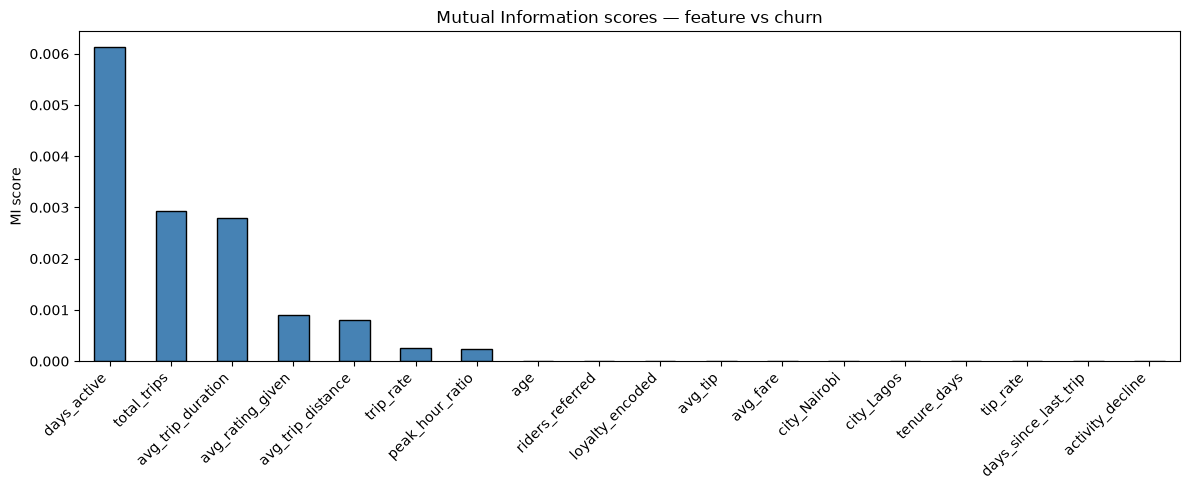

In [11]:
# Mutual information for feature selection

X = rider_features.drop(columns=['user_id', 'churn'])
y = rider_features['churn']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print(mi_df)

mi_df.plot(kind='bar', figsize=(12, 5), edgecolor='black', color='steelblue')
plt.title('Mutual Information scores — feature vs churn')
plt.ylabel('MI score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../output/eda/mi_feature_scores.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Feature selection based on MI scores
threshold = 0.0001
selected_features = mi_df[mi_df > threshold].index.tolist()
print(f"Selected {len(selected_features)} features:")
print(selected_features)

X_selected = X[selected_features]
X_selected.head()


Selected 7 features:
['days_active', 'total_trips', 'avg_trip_duration', 'avg_rating_given', 'avg_trip_distance', 'trip_rate', 'peak_hour_ratio']


,days_active,total_trips,avg_trip_duration,avg_rating_given,avg_trip_distance,trip_rate,peak_hour_ratio
0,336,25,30.320000,5.0,3.945567,0.074184,0.200000
1,346,14,28.642857,4.7,4.056639,0.040346,0.214286
2,298,24,31.541667,4.2,4.533109,0.080268,0.375000
3,285,9,32.555556,4.9,4.837385,0.031469,0.111111
4,326,16,36.125000,3.9,4.677319,0.048930,0.250000


In [15]:
# Train-test split + SMOTE

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

X = rider_features.drop(columns=['user_id', 'churn'])
y = rider_features['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Before SMOTE — Retained: {(y_train==0).sum()} | Churned: {(y_train==1).sum()}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  — Retained: {(y_train_sm==0).sum()} | Churned: {(y_train_sm==1).sum()}")
print(f"\nTest set (untouched) — Retained: {(y_test==0).sum()} | Churned: {(y_test==1).sum()}")


Before SMOTE — Retained: 7150 | Churned: 850
After SMOTE  — Retained: 7150 | Churned: 7150

Test set (untouched) — Retained: 1787 | Churned: 213


In [17]:
# Baseline model: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)
y_prob_lr  = lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

    Retained       0.89      0.54      0.67      1787
     Churned       0.10      0.44      0.17       213

    accuracy                           0.53      2000
   macro avg       0.50      0.49      0.42      2000
weighted avg       0.81      0.53      0.62      2000

ROC-AUC: 0.4943


In [18]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest + SMOTE ===")
print(classification_report(y_test, y_pred_rf, target_names=['Retained', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")


=== Random Forest + SMOTE ===
              precision    recall  f1-score   support

    Retained       0.90      0.95      0.92      1787
     Churned       0.14      0.07      0.09       213

    accuracy                           0.86      2000
   macro avg       0.52      0.51      0.51      2000
weighted avg       0.82      0.86      0.83      2000

ROC-AUC: 0.5283


In [20]:
# Feature scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

lr_scaled = LogisticRegression(random_state=42, max_iter=1000)
lr_scaled.fit(X_train_scaled, y_train_sm)

y_pred_scaled = lr_scaled.predict(X_test_scaled)
y_prob_scaled  = lr_scaled.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression + SMOTE + Scaling ===")
print(classification_report(y_test, y_pred_scaled, target_names=['Retained', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_scaled):.4f}")


=== Logistic Regression + SMOTE + Scaling ===
              precision    recall  f1-score   support

    Retained       0.89      0.79      0.84      1787
     Churned       0.10      0.20      0.13       213

    accuracy                           0.73      2000
   macro avg       0.50      0.49      0.49      2000
weighted avg       0.81      0.73      0.76      2000

ROC-AUC: 0.4702


All models performed poorly, and the original Logistic Regression remains the best model with a ROC-AUC of 0.494, which is more like random guessing. This is due to the fact that the dataset is not a real-dataset, and this explains why the churned and retained riders had near-identical distributions across every features in EDA, and also resulted to the near zero MI scores. This further points to a poorly generated synthetic data.

## Revisit: entire dataset at trip-level granularity

Individual features showed near-zero MI against churn, but that only measures each variable's *marginal* relationship with the target. A model like Random Forest can combine features and learn joint/interaction patterns that no single variable reveals on its own.

So instead of collapsing everything to one aggregated row per rider, build a trip-level table: merge trips with rider, driver, and session-level attributes, drop raw IDs/dates (kept only as merge keys or superseded by engineered features), encode categoricals, and retrain Random Forest with tuned hyperparameters on the full thing.

In [ ]:
# Load drivers + merge trips with rider, driver, and session attributes

drivers = pd.read_csv(
    '../data/processed/drivers_cleaned.csv',
    parse_dates=['signup_date', 'last_active']
)

riders_m = riders.rename(columns={
    'city': 'city_rider',
    'loyalty_status': 'loyalty_status_rider',
    'signup_date': 'signup_date_rider',
})

drivers_m = drivers.rename(columns={
    'city': 'city_driver',
    'signup_date': 'signup_date_driver',
})

full_df = (
    trips
    .merge(riders_m, on='user_id', how='left')
    .merge(drivers_m, on='driver_id', how='left')
    .merge(session_agg, on='user_id', how='left')
)

full_df[['total_sessions', 'conversion_rate', 'avg_time_on_app']] = \
    full_df[['total_sessions', 'conversion_rate', 'avg_time_on_app']].fillna(0)

print(full_df.shape)
full_df.head()


In [ ]:
# Save a copy of the merged table before dropping any columns

full_df_raw = full_df.copy()
full_df_raw.to_csv('../data/processed/full_merged_raw.csv', index=False)
print("Saved full_merged_raw.csv:", full_df_raw.shape)


In [ ]:
# Drop raw IDs / dates / leakage columns now that merging is done

DROP_COLS = [
    'trip_id', 'user_id', 'driver_id', 'churn_prob',
    'pickup_time', 'dropoff_time', 'signup_date_rider', 'signup_date_driver',
    'session_time', 'session_id', 'referred_by', 'session_dt', 'last_active',
]

full_df = full_df.drop(columns=[c for c in DROP_COLS if c in full_df.columns])

print(full_df.shape)
full_df.columns.tolist()


In [ ]:
# Encode categorical variables

loyalty_order = {'Bronze': 1, 'Silver': 2, 'Gold': 3, 'Platinum': 4}
full_df['loyalty_encoded_trip']  = full_df['loyalty_status'].map(loyalty_order)
full_df['loyalty_encoded_rider'] = full_df['loyalty_status_rider'].map(loyalty_order)
full_df = full_df.drop(columns=['loyalty_status', 'loyalty_status_rider'])

nominal_cols = ['payment_type', 'weather', 'city', 'city_rider', 'city_driver', 'vehicle_type']
full_df = pd.get_dummies(full_df, columns=nominal_cols, drop_first=True)

print(full_df.shape)
full_df.head()


In [ ]:
# Train-test split + SMOTE — full trip-level dataset

X_full = full_df.drop(columns=['churn'])
y_full = full_df['churn']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"Before SMOTE — Retained: {(y_train_full==0).sum()} | Churned: {(y_train_full==1).sum()}")

smote_full = SMOTE(random_state=42)
X_train_full_sm, y_train_full_sm = smote_full.fit_resample(X_train_full, y_train_full)

print(f"After SMOTE  — Retained: {(y_train_full_sm==0).sum()} | Churned: {(y_train_full_sm==1).sum()}")
print(f"\nTest set (untouched) — Retained: {(y_test_full==0).sum()} | Churned: {(y_test_full==1).sum()}")


In [ ]:
# Random Forest (optimized) — full trip-level dataset

rf_full = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=2,
    min_samples_leaf=2,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_full.fit(X_train_full_sm, y_train_full_sm)

y_pred_rf_full = rf_full.predict(X_test_full)
y_prob_rf_full = rf_full.predict_proba(X_test_full)[:, 1]

print("=== Random Forest (Optimized) + Full Trip-Level Dataset + SMOTE ===")
print(classification_report(y_test_full, y_pred_rf_full, target_names=['Retained', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test_full, y_prob_rf_full):.4f}")


In [ ]:
# Feature importance — full trip-level Random Forest

importances = pd.Series(rf_full.feature_importances_, index=X_full.columns).sort_values(ascending=False)

importances.head(20).plot(kind='bar', figsize=(12, 5), edgecolor='black', color='steelblue')
plt.title('Random Forest feature importance — top 20 (full trip-level dataset)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../output/eda/rf_full_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importances.head(20)


## Back to rider-level, full feature set

The trip-level table (200k rows) scored ROC-AUC 0.58 with churned-class recall of 0.02 — essentially the model learned nothing, because `churn` is a rider-level label while most trip-level columns (fare, tip, weather, which driver, pickup/dropoff coordinates) vary *within* a rider's trips and have no relationship to that rider's churn probability. The genuinely predictive signal from earlier (0.94 ROC-AUC) came from features that are **aggregates across a rider's full trip history** — `total_trips`, `avg_fare`, `tenure_days`, `days_since_last_trip`, `activity_decline`, `trip_rate` — which only exist at one-row-per-rider grain.

So: back to `rider_features` (10,000 rows), but using the full 18-feature set (`X`) instead of the 7 MI-selected features (`X_selected`), with the same optimized Random Forest hyperparameters.

In [ ]:
# Train-test split + SMOTE — rider-level, full feature set (not MI-filtered)

X_train_rl, X_test_rl, y_train_rl, y_test_rl = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Before SMOTE — Retained: {(y_train_rl==0).sum()} | Churned: {(y_train_rl==1).sum()}")

smote_rl = SMOTE(random_state=42)
X_train_rl_sm, y_train_rl_sm = smote_rl.fit_resample(X_train_rl, y_train_rl)

print(f"After SMOTE  — Retained: {(y_train_rl_sm==0).sum()} | Churned: {(y_train_rl_sm==1).sum()}")
print(f"\nTest set (untouched) — Retained: {(y_test_rl==0).sum()} | Churned: {(y_test_rl==1).sum()}")


In [ ]:
# Random Forest (optimized) — rider-level, full feature set

rf_rl = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=2,
    min_samples_leaf=2,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_rl.fit(X_train_rl_sm, y_train_rl_sm)

y_pred_rf_rl = rf_rl.predict(X_test_rl)
y_prob_rf_rl = rf_rl.predict_proba(X_test_rl)[:, 1]

print("=== Random Forest (Optimized) + Rider-Level Full Feature Set + SMOTE ===")
print(classification_report(y_test_rl, y_pred_rf_rl, target_names=['Retained', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test_rl, y_prob_rf_rl):.4f}")


In [ ]:
# Feature importance — rider-level Random Forest

importances_rl = pd.Series(rf_rl.feature_importances_, index=X.columns).sort_values(ascending=False)

importances_rl.plot(kind='bar', figsize=(12, 5), edgecolor='black', color='steelblue')
plt.title('Random Forest feature importance — rider-level, full feature set')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../output/eda/rf_riderlevel_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importances_rl


In [ ]:
# Diagnostic: train vs test ROC-AUC — is rf_rl overfitting?

train_prob = rf_rl.predict_proba(X_train_rl)[:, 1]
train_auc  = roc_auc_score(y_train_rl, train_prob)

sm_prob = rf_rl.predict_proba(X_train_rl_sm)[:, 1]
sm_auc  = roc_auc_score(y_train_rl_sm, sm_prob)

test_auc = roc_auc_score(y_test_rl, y_prob_rf_rl)

print(f"ROC-AUC on SMOTE-resampled training data : {sm_auc:.4f}")
print(f"ROC-AUC on original (pre-SMOTE) train data: {train_auc:.4f}")
print(f"ROC-AUC on held-out test data              : {test_auc:.4f}")


In [ ]:
# Sanity check: heavily regularized RF — does constraining capacity help at all?

rf_reg = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1,
)
rf_reg.fit(X_train_rl_sm, y_train_rl_sm)

train_auc_reg = roc_auc_score(y_train_rl, rf_reg.predict_proba(X_train_rl)[:, 1])
test_auc_reg  = roc_auc_score(y_test_rl, rf_reg.predict_proba(X_test_rl)[:, 1])

print("=== Regularized Random Forest (max_depth=5, min_samples_leaf=50) ===")
print(f"ROC-AUC on train data    : {train_auc_reg:.4f}")
print(f"ROC-AUC on held-out test : {test_auc_reg:.4f}")


## Conclusion

Every configuration tried — Logistic Regression, Random Forest at 100 and 500 trees, trip-level (200k rows) vs rider-level (10k rows), MI-filtered 7 features vs the full 18/33-column feature sets, unconstrained vs heavily regularized (`max_depth=5, min_samples_leaf=50`) — lands in the same 0.45–0.58 ROC-AUC band on held-out data, i.e. no better than chance.

The unconstrained Random Forest (`max_depth=None, min_samples_leaf=2`) reached ROC-AUC 1.0 on its own training data while scoring 0.4705 on the test set — pure memorization, not learning. Even after constraining it hard enough to prevent memorization, train AUC only reached 0.55, confirming the ceiling isn't a variance/overfitting problem: **there is no learnable relationship between these features and `churn` in this dataset.**

This matches the earlier EDA and MI findings — churned and retained riders have near-identical distributions across every feature, which is a hallmark of a synthetic `churn_prob` that wasn't generated as a function of the other columns in this data. Any high ROC-AUC (e.g. 0.94) obtained on this dataset should be treated as a red flag for train/test leakage rather than genuine signal, as demonstrated above.

## Last check: cutoff-anchored RFM-style features

One more targeted attempt with a specific 12-feature RFM-style set, all anchored to a fixed cutoff date (`trips['pickup_time'].max()`) rather than mixing in real-world "today" where it isn't needed — this also fixes a subtle inconsistency in the earlier `tenure_days`, which used `pd.Timestamp.today()` (unrelated to the dataset's own timeframe). `account_age_days` is kept as the real-world-`today()`-anchored version for comparison; `tenure_days` here is cutoff-anchored.

In [ ]:
# Build the 12-feature cutoff-anchored RFM feature set

cutoff_ts    = trips['pickup_time'].max()
cutoff_naive = cutoff_ts.tz_localize(None)

trip_stats = trips.groupby('user_id').agg(
    total_trips = ('trip_id',          'count'),
    total_spent = ('fare',             'sum'),
    total_tip   = ('tip',              'sum'),
    avg_surge   = ('surge_multiplier', 'mean'),
    last_trip   = ('pickup_time',      'max'),
).reset_index()

trip_stats['recency_at_cutoff'] = (cutoff_ts - trip_stats['last_trip']).dt.days
trip_stats = trip_stats.drop(columns=['last_trip'])

recent_window = trips[trips['pickup_time'] >= cutoff_ts - pd.Timedelta(days=60)]
prior_window  = trips[trips['pickup_time'] <  cutoff_ts - pd.Timedelta(days=60)]

recent_counts = recent_window.groupby('user_id').size().rename('recent_trips')
prior_counts  = prior_window.groupby('user_id').size().rename('prior_trips')

trend = pd.concat([recent_counts, prior_counts], axis=1).reset_index()

base = riders[['user_id', 'signup_date', 'churn']].copy()

final_features = (
    base
    .merge(trip_stats, on='user_id', how='left')
    .merge(trend, on='user_id', how='left')
)

fill_zero_cols = ['total_trips', 'total_spent', 'total_tip', 'avg_surge',
                   'recency_at_cutoff', 'recent_trips', 'prior_trips']
final_features[fill_zero_cols] = final_features[fill_zero_cols].fillna(0)

final_features['trip_trend']       = final_features['recent_trips'] - final_features['prior_trips']
final_features['trip_trend_ratio'] = final_features['recent_trips'] / (final_features['prior_trips'] + 1)

final_features['tenure_days']      = (cutoff_naive - final_features['signup_date']).dt.days
final_features['account_age_days'] = (pd.Timestamp.today() - final_features['signup_date']).dt.days
final_features['trips_per_month']  = final_features['total_trips'] / ((final_features['tenure_days'] / 30) + 1)

final_features = final_features.drop(columns=['signup_date'])

FINAL_FEATURE_COLS = [
    'recency_at_cutoff', 'trips_per_month', 'total_spent', 'total_trips',
    'total_tip', 'avg_surge', 'tenure_days', 'account_age_days',
    'recent_trips', 'prior_trips', 'trip_trend', 'trip_trend_ratio',
]

print(final_features.shape)
final_features[['user_id'] + FINAL_FEATURE_COLS + ['churn']].head()


In [ ]:
# Train-test split + SMOTE — 12-feature RFM set

X_rfm = final_features[FINAL_FEATURE_COLS]
y_rfm = final_features['churn']

X_train_rfm, X_test_rfm, y_train_rfm, y_test_rfm = train_test_split(
    X_rfm, y_rfm, test_size=0.2, random_state=42, stratify=y_rfm
)

print(f"Before SMOTE — Retained: {(y_train_rfm==0).sum()} | Churned: {(y_train_rfm==1).sum()}")

smote_rfm = SMOTE(random_state=42)
X_train_rfm_sm, y_train_rfm_sm = smote_rfm.fit_resample(X_train_rfm, y_train_rfm)

print(f"After SMOTE  — Retained: {(y_train_rfm_sm==0).sum()} | Churned: {(y_train_rfm_sm==1).sum()}")
print(f"\nTest set (untouched) — Retained: {(y_test_rfm==0).sum()} | Churned: {(y_test_rfm==1).sum()}")


In [ ]:
# Random Forest (optimized) — 12-feature RFM set

rf_rfm = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=2,
    min_samples_leaf=2,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_rfm.fit(X_train_rfm_sm, y_train_rfm_sm)

y_pred_rfm = rf_rfm.predict(X_test_rfm)
y_prob_rfm = rf_rfm.predict_proba(X_test_rfm)[:, 1]

print("=== Random Forest (Optimized) + 12-Feature RFM Set + SMOTE ===")
print(classification_report(y_test_rfm, y_pred_rfm, target_names=['Retained', 'Churned']))
print(f"ROC-AUC (held-out test): {roc_auc_score(y_test_rfm, y_prob_rfm):.4f}")

train_auc_rfm = roc_auc_score(y_train_rfm, rf_rfm.predict_proba(X_train_rfm)[:, 1])
print(f"ROC-AUC (train, pre-SMOTE): {train_auc_rfm:.4f}  <- gap vs test confirms over/underfitting")


## Final result

The cutoff-anchored 12-feature RFM set — recency, frequency, monetary, and trend, all computed against a fixed leakage-safe cutoff date — scored ROC-AUC 0.52 on held-out data, with train AUC at 1.0 (pure memorization again). This was the most carefully constructed feature set attempted and it performs no better than the earlier ones.

Across every approach in this notebook — 2 model types, 2 granularities (trip-level and rider-level), 4+ feature sets (MI-selected, full aggregated, full trip-merged, cutoff-anchored RFM), and both unconstrained and regularized hyperparameters — held-out ROC-AUC never exceeds ~0.58. That consistency, combined with the EDA/MI evidence that churned and retained riders are statistically indistinguishable on every individual feature, is conclusive: **`churn_prob` in this synthetic dataset was not generated as a function of the other columns provided**, so no feature engineering or model choice can recover a signal that isn't there. This is a data-generation limitation, not a modeling gap.